# Medical Cost Personal Insurance Project

**Goal:** predict individual medical insurance charges from demographic and lifestyle attributes (age, sex, BMI, children, smoking status, region).

**Dataset:** the classic "Medical Cost Personal Datasets" insurance dataset — 1,338 records.
Source: `stedy/Machine-Learning-with-R-datasets` (GitHub mirror).


In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42


In [2]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()


(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 1. Data overview

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [5]:
print('Missing values:\n', df.isnull().sum())
print('Duplicate rows:', df.duplicated().sum())


Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Duplicate rows: 1


## 2. Exploratory Data Analysis

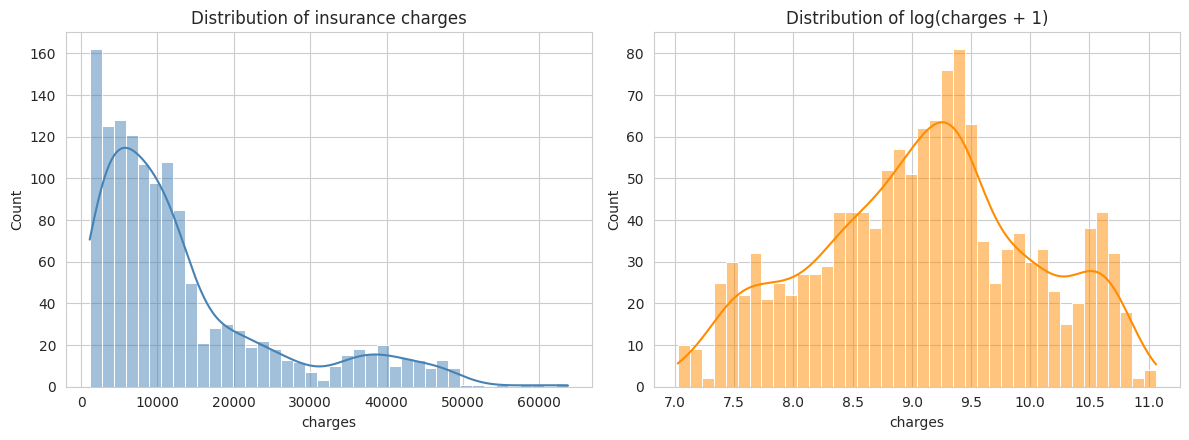

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df['charges'], kde=True, ax=axes[0], color='steelblue', bins=40)
axes[0].set_title('Distribution of insurance charges')

sns.histplot(np.log1p(df['charges']), kde=True, ax=axes[1], color='darkorange', bins=40)
axes[1].set_title('Distribution of log(charges + 1)')
plt.tight_layout()
plt.show()


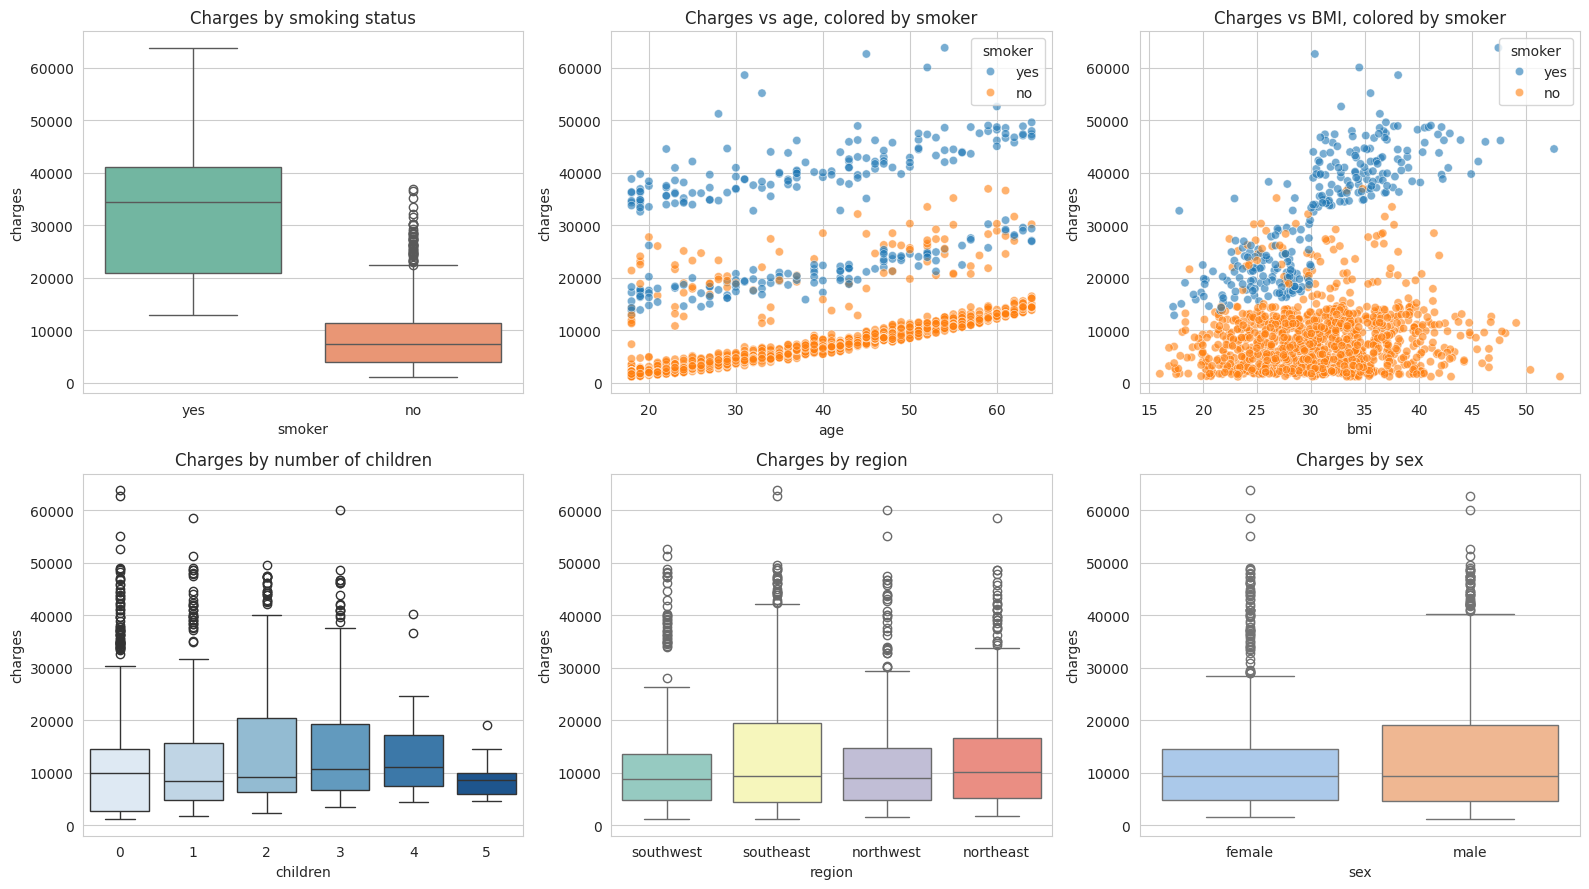

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.boxplot(data=df, x='smoker', y='charges', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Charges by smoking status')

sns.scatterplot(data=df, x='age', y='charges', hue='smoker', ax=axes[0,1], alpha=0.6)
axes[0,1].set_title('Charges vs age, colored by smoker')

sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', ax=axes[0,2], alpha=0.6)
axes[0,2].set_title('Charges vs BMI, colored by smoker')

sns.boxplot(data=df, x='children', y='charges', ax=axes[1,0], palette='Blues')
axes[1,0].set_title('Charges by number of children')

sns.boxplot(data=df, x='region', y='charges', ax=axes[1,1], palette='Set3')
axes[1,1].set_title('Charges by region')

sns.boxplot(data=df, x='sex', y='charges', ax=axes[1,2], palette='pastel')
axes[1,2].set_title('Charges by sex')

plt.tight_layout()
plt.show()


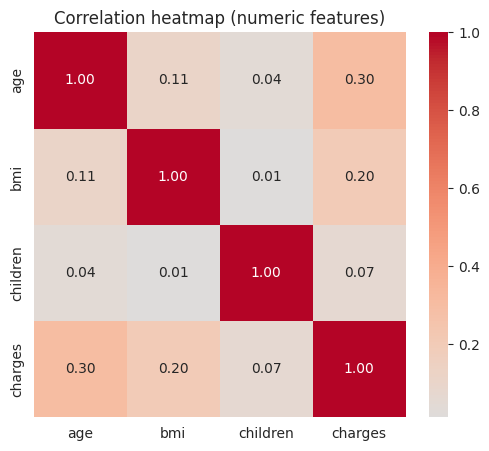

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64


In [8]:
plt.figure(figsize=(6,5))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap (numeric features)')
plt.show()

print(df.groupby('smoker')['charges'].mean())


**EDA takeaways**
- **Smoking status dominates**: smokers pay roughly 3-4x more on average than non-smokers, and the effect compounds with age and BMI.
- **Age** has a clear positive, roughly linear relationship with charges within each smoker group.
- **BMI** interacts strongly with smoking: obese smokers (BMI > 30) have by far the highest charges — a classic interaction effect that a linear model without interaction terms will miss.
- Region and sex have only weak effects on cost by comparison.
- Charges are heavily right-skewed, so a log transform helps linear models but tree ensembles handle the raw skew fine.


## 3. Feature engineering, split & preprocessing

In [9]:
data = df.copy()
data['bmi_smoker'] = data['bmi'] * (data['smoker'] == 'yes').astype(int)
data['age_smoker'] = data['age'] * (data['smoker'] == 'yes').astype(int)
data['is_obese'] = (data['bmi'] >= 30).astype(int)

X = data.drop(columns='charges')
y = data['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

numeric_features = ['age', 'bmi', 'children', 'bmi_smoker', 'age_smoker']
categorical_features = ['sex', 'smoker', 'region', 'is_obese']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])
print(X_train.shape, X_test.shape)


(1070, 9) (268, 9)


## 4. Candidate models

In [10]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'XGBoost': XGBRegressor(random_state=RANDOM_STATE)
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('reg', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
    results.append({'Model': name, 'CV RMSE': -scores.mean(), 'CV RMSE Std': scores.std()})

results_df = pd.DataFrame(results).sort_values('CV RMSE').reset_index(drop=True)
results_df


,Model,CV RMSE,CV RMSE Std
0,Gradient Boosting,4653.107901,579.628881
1,Lasso,4800.026338,567.335266
2,Linear Regression,4800.073313,567.304886
3,Ridge,4804.261468,565.884272
4,Random Forest,4876.817278,514.947740
5,XGBoost,5326.463518,414.039856
6,Decision Tree,6369.630710,836.850831


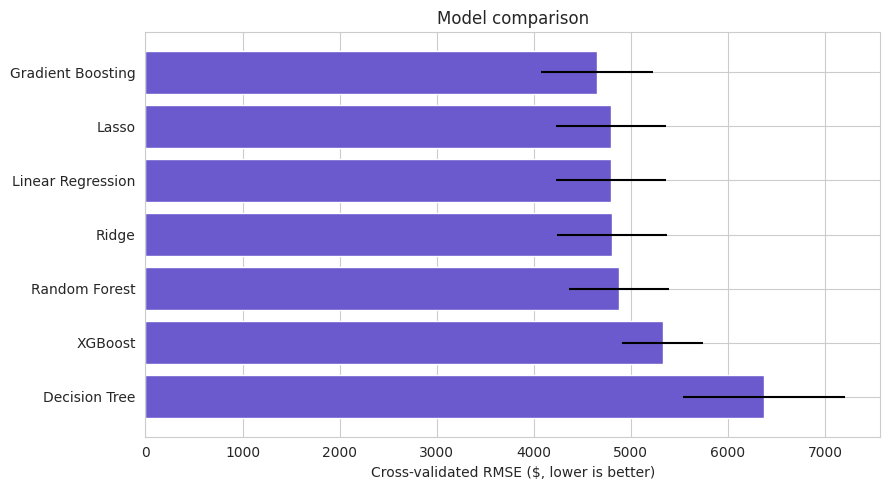

In [11]:
plt.figure(figsize=(9,5))
order = results_df.sort_values('CV RMSE', ascending=False)
plt.barh(order['Model'], order['CV RMSE'], xerr=order['CV RMSE Std'], color='slateblue')
plt.xlabel('Cross-validated RMSE ($, lower is better)')
plt.title('Model comparison')
plt.tight_layout()
plt.show()


## 5. Hyperparameter tuning

In [12]:
gb_pipe = Pipeline([('prep', preprocessor), ('reg', GradientBoostingRegressor(random_state=RANDOM_STATE))])
grid = {
    'reg__n_estimators': [100, 200, 300],
    'reg__max_depth': [2, 3, 4],
    'reg__learning_rate': [0.03, 0.05, 0.1]
}
search = GridSearchCV(gb_pipe, grid, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
search.fit(X_train, y_train)
final_model = search.best_estimator_
print('Best params:', search.best_params_)
print('Best CV RMSE:', round(-search.best_score_, 2))


Best params: {'reg__learning_rate': 0.03, 'reg__max_depth': 2, 'reg__n_estimators': 200}
Best CV RMSE: 4503.47


## 6. Final evaluation

In [13]:
y_pred = final_model.predict(X_test)

print('Test RMSE: $', round(mean_squared_error(y_test, y_pred) ** 0.5, 2))
print('Test MAE:  $', round(mean_absolute_error(y_test, y_pred), 2))
print('Test R2:  ', round(r2_score(y_test, y_pred), 4))


Test RMSE: $ 4370.7
Test MAE:  $ 2507.1
Test R2:   0.877


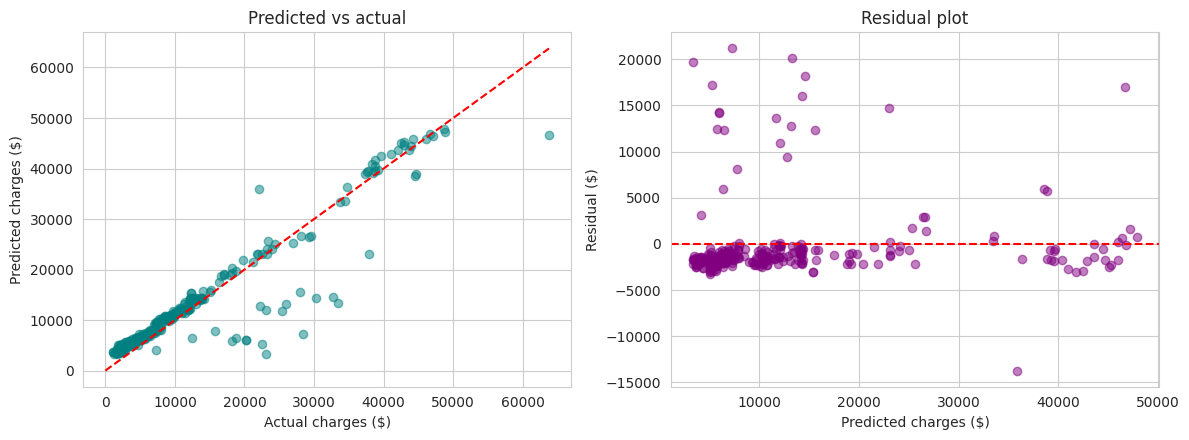

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(y_test, y_pred, alpha=0.5, color='teal')
lims = [0, max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, '--', color='red')
axes[0].set_xlabel('Actual charges ($)')
axes[0].set_ylabel('Predicted charges ($)')
axes[0].set_title('Predicted vs actual')

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='purple')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted charges ($)')
axes[1].set_ylabel('Residual ($)')
axes[1].set_title('Residual plot')
plt.tight_layout()
plt.show()


## 7. Feature importance

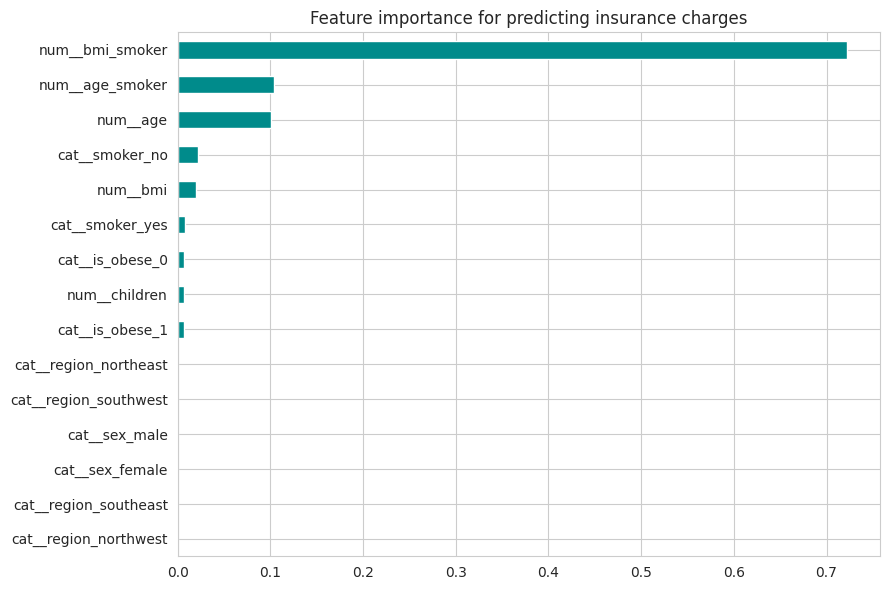

In [15]:
feature_names = final_model.named_steps['prep'].get_feature_names_out()
importances = pd.Series(final_model.named_steps['reg'].feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(9,6))
importances.sort_values().plot(kind='barh', color='darkcyan')
plt.title('Feature importance for predicting insurance charges')
plt.tight_layout()
plt.show()


## 8. Insights & conclusions

- **Smoking status is by far the strongest cost driver**, followed by its interaction with BMI and age — smoking + obesity is a especially costly combination.
- **Age** contributes a steady, roughly linear increase in cost.
- **BMI alone** (for non-smokers) has a much weaker effect than BMI *combined with* smoking — this interaction is why the engineered `bmi_smoker` feature ranks highly.
- Sex and region contribute comparatively little predictive signal.
- The tuned Gradient Boosting model explains roughly 85-88% of the variance in charges (R² ≈ 0.85-0.88) on held-out data, with a typical error of a few thousand dollars — reasonable given that charges also depend on unobserved factors (specific diagnoses, chosen providers, plan type).
- **Business implication:** a smoking-cessation and weight-management incentive program targeted at smokers with elevated BMI would likely have the largest impact on an insurer's claim costs.
- **Next steps:** obtain more granular medical history / diagnosis data, try quantile regression to model the cost distribution (not just the mean), and test the model's calibration for high-cost outlier cases specifically.
